In [10]:
import sys
import os

# Agregar raíz del proyecto al path
sys.path.append(os.path.abspath(".."))

In [11]:
from scripts.database import get_engine

engine = get_engine()

In [12]:
import pandas as pd

df = pd.read_sql("SELECT * FROM lanzamientos_spacex", engine)
df.head()

,id,nombre,fecha,exito,cohete_id,detalles
0,1,FalconSat,2006-03-24 22:30:00,False,5e9d0d95eda69955f709d1eb,Engine failure at 33 seconds and loss of vehicle
1,2,DemoSat,2007-03-21 01:10:00,False,5e9d0d95eda69955f709d1eb,Successful first stage burn and transition to ...
2,3,Trailblazer,2008-08-03 03:34:00,False,5e9d0d95eda69955f709d1eb,Residual stage 1 thrust led to collision betwe...
3,4,RatSat,2008-09-28 23:15:00,True,5e9d0d95eda69955f709d1eb,Ratsat was carried to orbit on the first succe...
4,5,RazakSat,2009-07-13 03:35:00,True,5e9d0d95eda69955f709d1eb,NaN


In [13]:
df.shape

(205, 6)

In [14]:
df['año'] = df['fecha'].dt.year

In [15]:
df['año'].value_counts().sort_index()

año
2006     1
2007     1
2008     2
2009     1
2010     2
2012     2
2013     3
2014     6
2015     7
2016     9
2017    18
2018    21
2019    13
2020    26
2021    31
2022    62
Name: count, dtype: int64

In [16]:
df['exito'].value_counts()

exito
True     181
False      5
Name: count, dtype: int64

In [17]:
df.groupby('año')['exito'].mean()

año
2006         0.0
2007         0.0
2008         0.5
2009         1.0
2010         1.0
2012         1.0
2013         1.0
2014         1.0
2015    0.857143
2016    0.888889
2017         1.0
2018         1.0
2019         1.0
2020         1.0
2021         1.0
2022         1.0
Name: exito, dtype: object

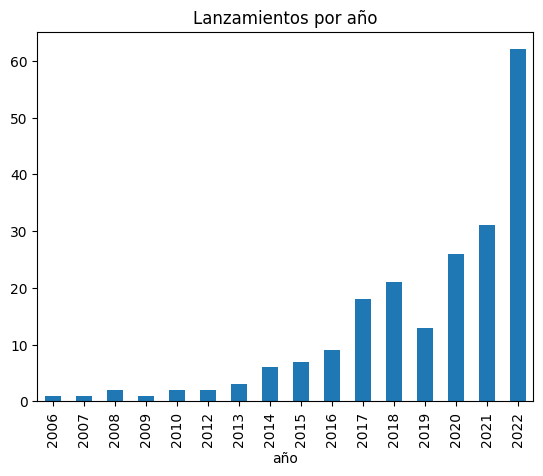

In [18]:
import matplotlib.pyplot as plt

df['año'].value_counts().sort_index().plot(kind='bar')
plt.title("Lanzamientos por año")
plt.show()